# QuSpin ZXZ Y - rdm tensor network factorization

Created: 12-06-2026

Objectives:

In the [previous notebook](quspin_zxz_y_defects.ipynb), we encountered issues with the wavefunctions of the purifications being long range entangled. I think we can get around this by employing a [tensor network factorization](https://quimb.readthedocs.io/en/latest/examples/ex_tn_tensor_fitting.html).

1. Find $\rho$.
2. Find a tensor network factorization of $\rho$.
3. Extract resulting purified states.
4. Check schmidt decomposition, short range entangled.

We will use a Hamiltonian of the form $\sum_i (-t*Z_{i-1}X_i Z_{i+1} -(1-t)*Y)$ to test this, which has an $XK$ time reversal symmetry.

# Imports

In [1]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
from tqdm import tqdm

In [4]:
from functools import reduce

In [5]:
import quimb.tensor as qtn
import quimb as qu

# Analysis

## Find grounstate

In [6]:
num_sites = 16

In [7]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [8]:
# Use periodic boundary conditions.
def get_hamiltoniain(t, L=10):
    static = [
        ["zxz", [[-t, i, (i+1)%L, (i+2)%L] for i in range(L)]],
        ["y", [[-(1-t), i] for i in range(L)]],
    ]
    dynamic = []

    basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)
    out = hamiltonian(
        static,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return out

In [9]:
parameter = 0.8

In [10]:
hamiltonian = get_hamiltoniain(parameter, num_sites)

In [11]:
e, psi = hamiltonian.eigsh(k=1, which='SA')

In [12]:
e

array([-12.93427729])

## Find $\rho$

In [13]:
symmetry_sites = list(range(4, 12))

num_symmetry_sites = len(symmetry_sites)

In [14]:
basis = spin_basis_1d(num_sites, S="1/2", pauli=-1)

In [15]:
rho = basis.partial_trace(
    psi,
    sub_sys_A=symmetry_sites,
    return_rdm="A",
    enforce_pure=True
)

## Set up optimization

In [16]:
rho.shape

(256, 256)

In [17]:
rho_reshaped = rho.reshape((16, 16, 16, 16,))

In [18]:
qt_rho = qtn.Tensor(
    data=rho_reshaped,
    inds=('lk', 'rk', 'lb', 'rb')
)

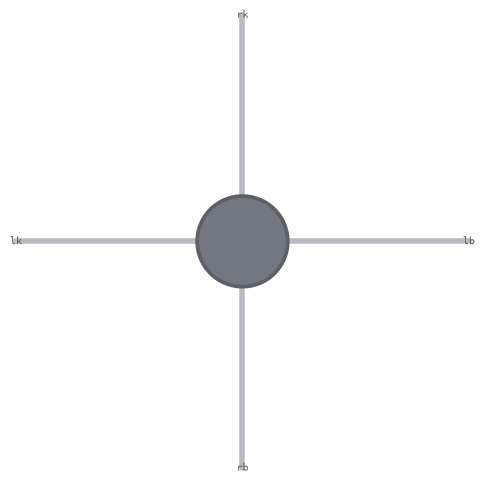

In [19]:
qt_rho.draw()

In [20]:
qt_rho.norm()

np.float64(0.4999856635057033)

In [21]:
np.trace(rho)

np.complex128(1.0000000000000013+0j)

In [22]:
horiztonal_bond_dimension = 16
vertical_bond_dimension = 4

In [23]:
A_left = qtn.Tensor(
    data=np.random.uniform(size=(vertical_bond_dimension, 2**4, horiztonal_bond_dimension)),
    inds=('vLV', 'kl', 'vH')
)

A_right = qtn.Tensor(
    data=np.random.uniform(size=(horiztonal_bond_dimension, 2**4, vertical_bond_dimension)),
    inds=('vH', 'kr', 'vRV')
)

In [24]:
rho_purity = np.trace(rho @ rho)

In [25]:
rho_purity

np.complex128(0.24998566371123832-8.381265293170316e-21j)

In [26]:
rho_purity = np.real(rho_purity)

In [27]:
A = qtn.TensorNetwork([A_left, A_right])

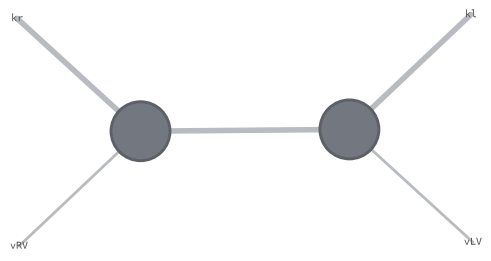

In [28]:
A.draw()

In [29]:
def get_rho_A(A):
    A_bottom = A.conj().reindex({'kl': 'bl', 'kr': 'br'})
    return A & A_bottom

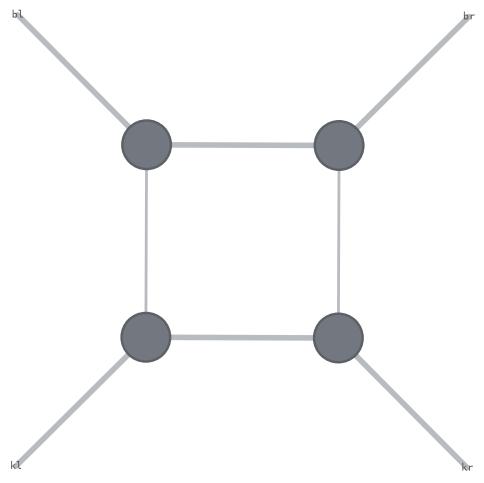

In [30]:
get_rho_A(A).draw()

In [31]:
rho_A = get_rho_A(A)

In [32]:
def rho_A_trace(rho_A):
    out = (
        rho_A
        .reindex({'bl': 'kl', 'br': 'kr'})
        .contract()
    )
    return out

In [33]:
rho_A_trace(rho_A)

np.float64(73464.18469563461)

In [34]:
rho_A_trace(rho_A/2)

np.float64(36732.092347817306)

In [35]:
rho_A_trace(rho_A.multiply(0.5))

np.float64(36732.092347817306)

In [36]:
rho_A_trace(rho_A.multiply(0.5))**(-1)

np.float64(2.722415022076525e-05)

In [37]:
def normalize_rho_A(rho_A):
    trace = rho_A_trace(rho_A)
    return rho_A.multiply(trace**(-1))

In [38]:
tn = (
    (rho_A.reindex({'bl': 'kl', 'br': 'kr'}))
    & rho_A
)

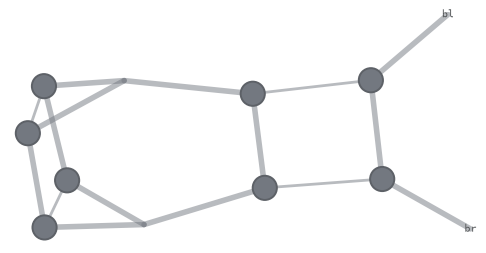

In [39]:
tn.draw()

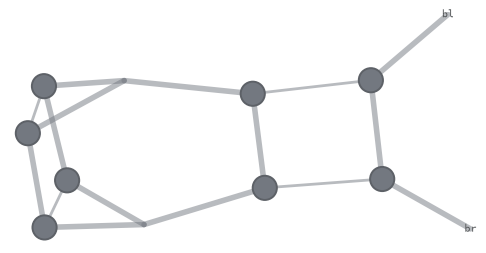

In [40]:
tn.draw()

In [41]:
tn

TensorNetwork(tensors=8, indices=12)

In [42]:
transpose_reindex_dict = {
    'bl': 'kl',
    'br': 'kr',
    'kl': 'bl',
    'kr': 'br'
}

In [43]:
def rho_A_purity(rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho_A
    )

    out = tn.contract()

    return out

In [44]:
rho_A_purity(rho_A)

np.float64(5004475838.005076)

In [45]:
def rho_A_rho_overlap(rho, rho_A):
    tn = (
        (rho_A.reindex(transpose_reindex_dict))
        & rho
    )

    out = tn.contract()

    return out

In [46]:
rho.shape

(256, 256)

In [47]:
qu_rho = qtn.Tensor(
    data=rho.reshape(16, 16, 16, 16),
    inds=('kl', 'kr', 'bl', 'br')
)

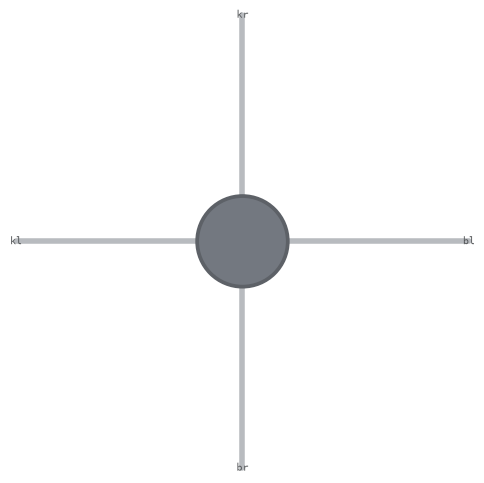

In [48]:
qu_rho.draw()

In [49]:
def loss_func(A, rho):
    rho_A = get_rho_A(A)

    out = np.real(
        rho_purity
        + rho_A_purity(rho_A)
        -2*rho_A_rho_overlap(rho, rho_A)
    )

    return out

In [50]:
rho_A = normalize_rho_A(rho_A)

In [51]:
def normalize_A(A):
    rho_A = get_rho_A(A)
    trace = rho_A_trace(rho_A)
    return A.multiply(trace**(-0.5))

In [52]:
tnopt = qtn.TNOptimizer(
    A,  # the tensor network we want to optimize
    loss_func,  # the function we want to minimize
    norm_fn=normalize_A,
    loss_constants={"rho": qu_rho},  # supply U to the loss function as a constant TN
    autodiff_backend="jax",  # use 'autograd' for non-compiled optimization
    optimizer="L-BFGS-B",  # the optimization algorithm
)

In [53]:
A_opt = tnopt.optimize_basinhopping(n=100,  nhop=5)

  0%|                                                                                                           | 0/500 [00:00<?, ?it/s]E0612 15:03:34.085277    7399 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p314/lib/python3.14/site-packages/quimb/tensor/optimize.py:135: UserWarning: dtype mismatch between input parameter and updated values. This can occur e.g. with jax and double precision arrays (in which case consider setting `jax.config.update("jax_enable_x64", True)` at startup or using single precision parameters directly). For now casting from float32 to float64.
  warnings.warn(
+0.007065325975 [best: +0.007010012865] :   7%|███▉                                                    | 35/500 [00:00<00:11, 41.36it/s]


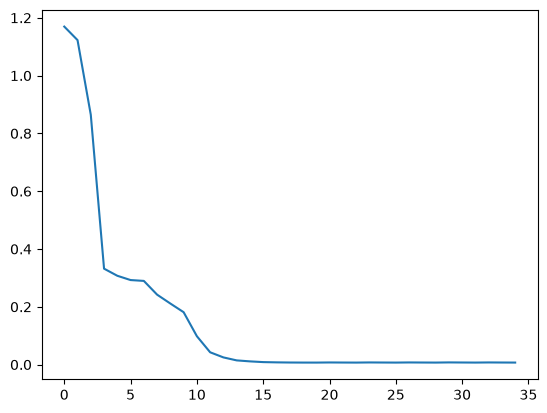

In [54]:
plt.plot(tnopt.losses)

In [55]:
tnopt.loss_best

0.007010012865066528

In [56]:
A_opt

TensorNetwork(tensors=2, indices=5)

In [57]:
A_l_opt = A_opt.tensors[0]

In [58]:
tn_l = (
    A_l_opt
    &
    A_l_opt.conj().reindex({'kl': 'bl', 'vH': 'vBH'})
)

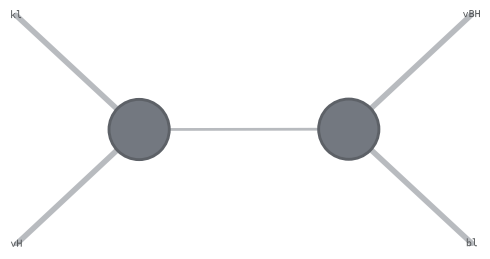

In [59]:
tn_l.draw()

In [60]:
tn_l = tn_l.contract()

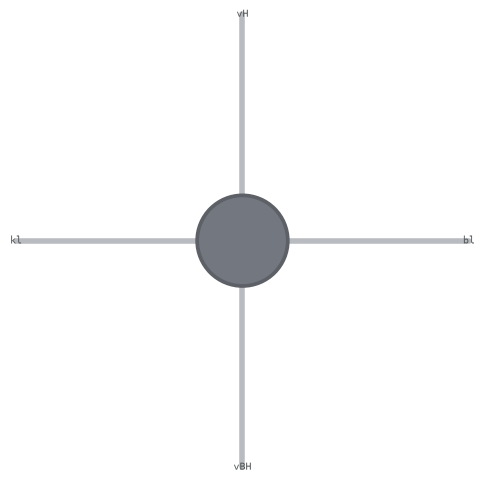

In [61]:
tn_l.draw()

In [62]:
left_eig_out = qtn.tensor_core.tensor_split(
    tn_l,
    left_inds=['kl', 'vH'],
    method='eigh',
    cutoff=1e-6,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vLV'
)

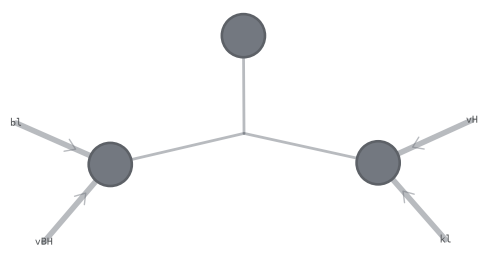

In [63]:
left_eig_out.draw()

In [64]:
left_eig_out.tensors[1].data

array([0.61066914, 0.6085745 , 0.01197002, 0.00750259], dtype=float32)

In [65]:
A_r_opt = A_opt.tensors[1]

In [66]:
tn_r = (
    A_r_opt
    &
    A_r_opt.conj().reindex({'kr': 'br', 'vH': 'vBH'})
)

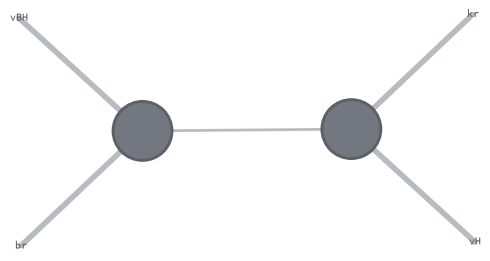

In [67]:
tn_r.draw()

In [68]:
tn_r = tn_r.contract()

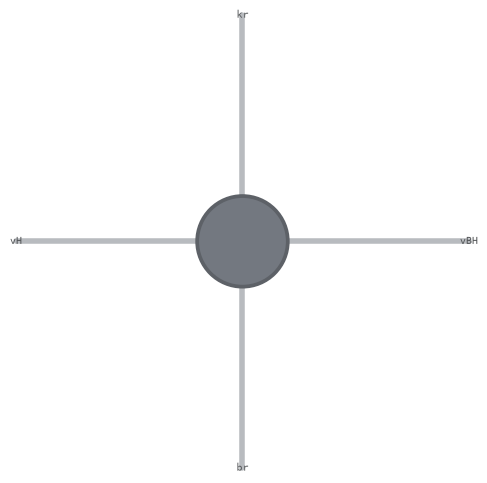

In [69]:
tn_r.draw()

In [70]:
right_eig_out = qtn.tensor_core.tensor_split(
    tn_r,
    left_inds=['kr', 'vH'],
    method='eigh',
    cutoff=1e-3,
    cutoff_mode='abs',
    absorb=None,
    renorm=True,
    bond_ind='vRV'
)

In [71]:
right_eig_out

TensorNetwork(tensors=3, indices=5)

In [72]:
right_eig_out.tensors[1].data

array([-0.5725018 ,  0.563942  , -0.47563067,  0.46839914,  0.22144674,
       -0.20876493,  0.20810367, -0.18078242,  0.12150957, -0.11870019,
       -0.10004769,  0.09341926,  0.08711231, -0.08216344,  0.07935476,
       -0.07419459,  0.07370602, -0.07129691,  0.06504983, -0.06349099,
       -0.05847211,  0.05370533,  0.05089541, -0.04674563, -0.04641617,
        0.04210962,  0.04190112, -0.03972604, -0.03673208,  0.03645827,
        0.03450206, -0.03428201,  0.02963072, -0.02881112, -0.02744954,
       -0.02539769,  0.02421984, -0.023607  , -0.0231448 ,  0.02235819,
       -0.02130102,  0.02040561, -0.01993328,  0.01976208, -0.01947205,
        0.01836384,  0.01770762, -0.01759114,  0.01693188, -0.01681647,
        0.01637318, -0.01619134, -0.01594355,  0.01542129, -0.01506289,
        0.01494491, -0.014697  ,  0.01462678,  0.01439824, -0.01420692,
        0.01419126,  0.01337126,  0.01316665, -0.01260246,  0.01190291,
        0.01172088,  0.01122918, -0.01094126,  0.01044807, -0.01

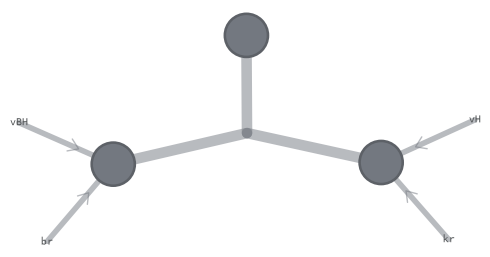

In [73]:
right_eig_out.draw()

In [74]:
purified_states = (
    left_eig_out.tensors[0]
    & right_eig_out.tensors[0]
)

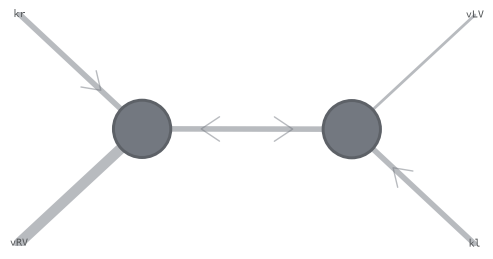

In [75]:
purified_states.draw()

In [77]:
help(purified_states.isel)

Help on method isel in module quimb.tensor.tensor_core:

isel(selectors, inplace=False) method of quimb.tensor.tensor_core.TensorNetwork instance
    Select specific values for some dimensions/indices of this tensor
    network, thereby removing them.

    Parameters
    ----------
    selectors : dict[str, int or slice or "r"]
        Mapping of index(es) to which value to take. The values can be:

        - int: select a specific value for that index.
        - slice: select a range of values for that index.
        - "r": contract a random vector in.

    inplace : bool, optional
        Whether to select inplace or not.

    Returns
    -------
    TensorNetwork

    See Also
    --------
    Tensor.isel



In [78]:
psi_0 = purified_states.isel({'vRV': 0, 'vLV': 0})

In [ ]:
help(psi_0.unfuse

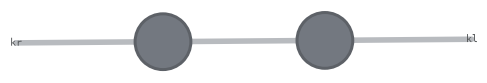

In [79]:
psi_0.draw()

In [80]:
psi_0

TensorNetwork(tensors=2, indices=3)

In [81]:
help(psi_0.tensors[0].unfuse)

Help on method unfuse in module quimb.tensor.tensor_core:

unfuse(unfuse_map, shape_map, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Reshape single indices into groups of multiple indices

    Parameters
    ----------
    unfuse_map : dict_like or sequence of tuples.
        Mapping like: ``{existing_ind: sequence of new inds, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_inds_1), ...]`` in which
        case the output tensor's new inds will be ordered. In both cases
        the new indices are created at the old index's position of the
        tensor's shape
    shape_map : dict_like or sequence of tuples
        Mapping like: ``{old_ind: new_ind_sizes, ...}`` or an
        ordered mapping like ``[(old_ind_1, new_ind_sizes_1), ...]``.

    Returns
    -------
    Tensor
        The transposed, reshaped and re-labeled tensor



In [82]:
help(psi_0.tensors[0].unfuse_)

Help on partial in module functools:

functools.partial(<bound method Tensor.unfuse of...inds=('kl', 'vH'), tags=oset([]))>, inplace=True)


In [86]:
psi_0.tensors[0]

Tensor(shape=(16, 16), inds=('kl', 'vH'), tags=oset([]))

In [87]:
(
    psi_0
    .tensors[0]
    .unfuse_(
        unfuse_map={'kl': ['kl1', 'kl2']},
        shape_map={'kl': (4, 4)}
    )
)

Tensor(shape=(4, 4, 16), inds=('kl1', 'kl2', 'vH'), tags=oset([]))

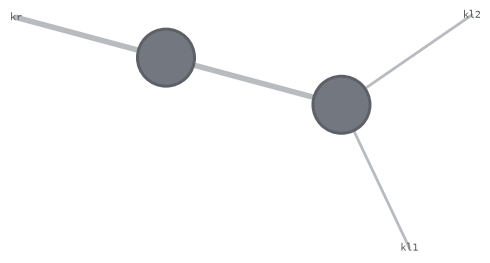

In [88]:
psi_0.draw()

In [89]:
(
    psi_0
    .tensors[1]
    .unfuse_(
        unfuse_map={'kr': ['kr1', 'kr2']},
        shape_map={'kr': (4, 4)}
    )
)

Tensor(shape=(4, 4, 16), inds=('kr1', 'kr2', 'vH'), tags=oset([]))

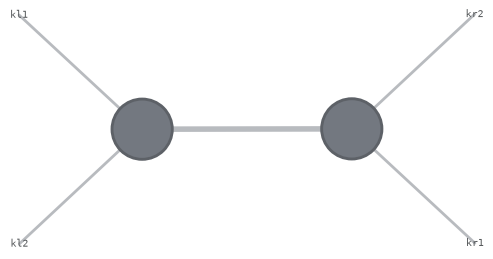

In [90]:
psi_0.draw()

In [91]:
rho_0 = (
    psi_0
    & psi_0.conj().reindex({'kl1': 'bl1', 'kr2': 'br2'})
)

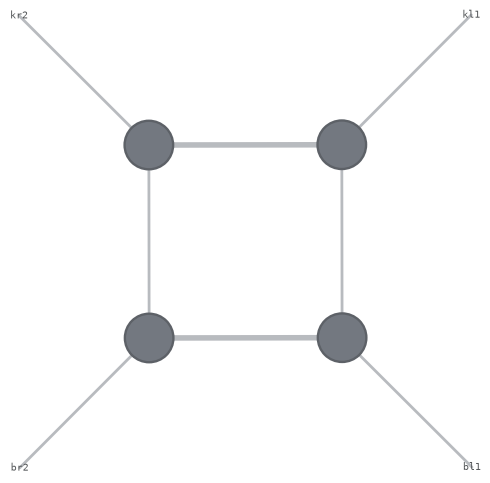

In [92]:
rho_0.draw()

In [95]:
rho_0.contract(inplace=True)

TensorNetwork(tensors=1, indices=4)

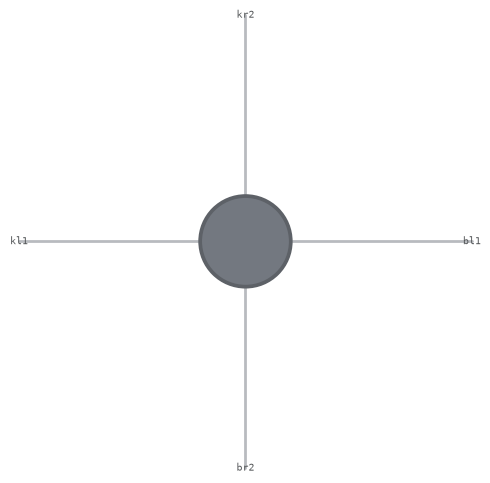

In [96]:
rho_0.draw()

In [97]:
rho_0 = rho_0.tensors[0]

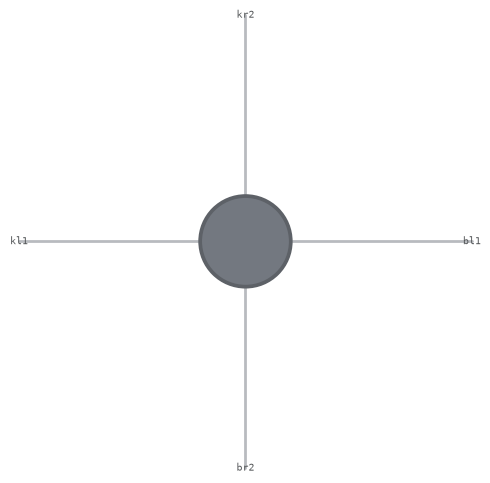

In [98]:
rho_0.draw()

In [99]:
rho_0

Tensor(shape=(4, 4, 4, 4), inds=('kl1', 'kr2', 'bl1', 'br2'), tags=oset([]))

In [100]:
split_rho_0 = qtn.tensor_core.tensor_split(
    rho_0,
    left_inds=['kl1', 'bl1'],
    absorb=None
)

In [101]:
split_rho_0

TensorNetwork(tensors=3, indices=5)

In [102]:
split_rho_0.tensors[1].data

array([1.6193019e-01, 1.2087455e-03, 8.8881818e-04, 6.4324203e-04,
       4.0388401e-04, 3.9499841e-04, 2.1209242e-04, 1.3395169e-04,
       8.8151151e-05, 6.6288194e-05, 3.6676218e-05, 1.1779943e-05,
       1.1284050e-05, 6.4286087e-07, 1.3481920e-07, 4.2938044e-08],
      dtype=float32)

## Compute $E$ and extract defect operators

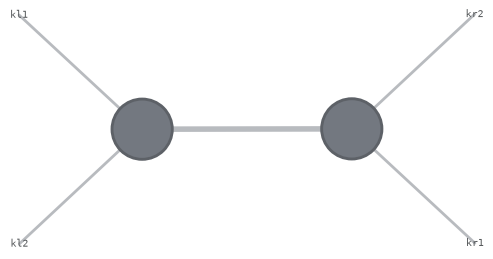

In [104]:
psi_0.draw()

In [105]:
np_X = np.array([
    [0,1],
    [1,0]
])

In [106]:
np_XX = np.kron(np_X, np_X)

In [107]:
np_XX

array([[0, 0, 0, 1],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       [1, 0, 0, 0]])

In [108]:
qu_XX = qtn.Tensor(
    np_XX,
    inds=['k', 'b']
)

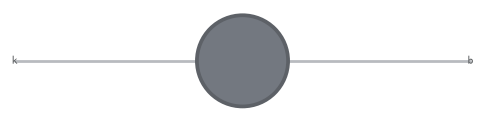

In [109]:
qu_XX.draw()

Let `edm` denote $E$.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


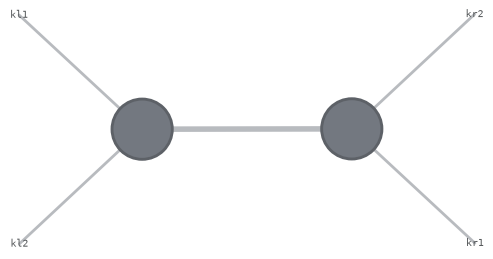

In [110]:
psi_0.draw()

In [123]:
edm = (
    psi_0
    & qu_XX.reindex({'k': 'bl1', 'b': 'bbl1'})
    & qu_XX.reindex({'k': 'kl2', 'b': 'br2'})
    & qu_XX.reindex({'k': 'kr1', 'b': 'br1'})
    & qu_XX.reindex({'k': 'br2', 'b': 'bbr2'})
    & psi_0.reindex({
        'kl1': 'bbl1', 'kl2': 'bl2', 'kr1': 'br1', 'kr2': 'bbr2'
    })
)

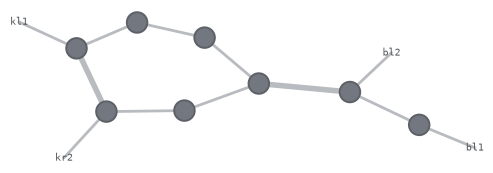

In [124]:
edm.draw()

In [125]:
edm = edm.contract()

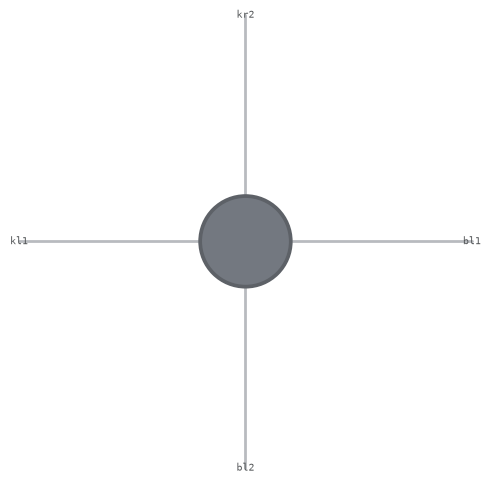

In [126]:
edm.draw()

Take schmidt decomposition

In [131]:
split_edm = qtn.tensor_core.tensor_split(
    rho_0,
    left_inds=['kl1', 'bl1'],
    absorb=None,
    bond_ind='vH'
)

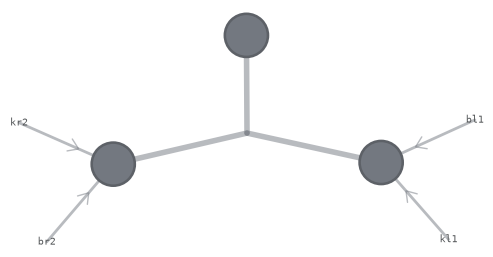

In [147]:
split_edm.draw()

In [133]:
split_edm.tensors[1].data

array([1.6193019e-01, 1.2087455e-03, 8.8881818e-04, 6.4324203e-04,
       4.0388401e-04, 3.9499841e-04, 2.1209242e-04, 1.3395169e-04,
       8.8151151e-05, 6.6288194e-05, 3.6676218e-05, 1.1779943e-05,
       1.1284050e-05, 6.4286087e-07, 1.3481920e-07, 4.2938044e-08],
      dtype=float32)

In [134]:
split_edm.tensors[0]

Tensor(shape=(4, 4, 16), inds=('kl1', 'bl1', 'vH'), tags=oset([]), left_inds=('kl1', 'bl1'))

In [135]:
split_edm

TensorNetwork(tensors=3, indices=5)

In [136]:
left_edm = split_edm.tensors[0].isel({'vH': 0})

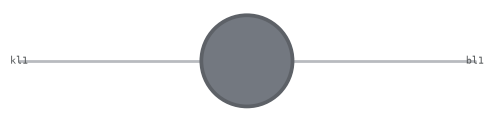

In [137]:
left_edm.draw()

In [138]:
u, s, vh = qtn.tensor_core.tensor_split(
    left_edm,
    left_inds=['kl1'],
    absorb=None,
    bond_ind='v'
)

In [143]:
left_defect_operator = (
    (u & vh)
    .contract()
    .conj()
    .reindex({'kl1': 'bl1', 'bl1': 'kl1'})
)

In [144]:
left_defect_operator

Tensor(shape=(4, 4), inds=('bl1', 'kl1'), tags=oset([]))

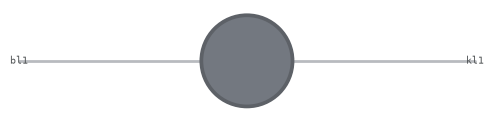

In [145]:
left_defect_operator.draw()

## Compute invariant

In [146]:
rho_0

Tensor(shape=(4, 4, 4, 4), inds=('kl1', 'kr2', 'bl1', 'br2'), tags=oset([]))

In [148]:
rho_0_l = rho_0.reindex({'br2': 'kr2'}).contract()

In [149]:
rho_0_l

Tensor(shape=(4, 4), inds=('kl1', 'bl1'), tags=oset([]))

In [150]:
qu_XX

Tensor(shape=(4, 4), inds=('k', 'b'), tags=oset([]))

In [162]:
left_defect_op_invariant = (
    rho_0_l
    & left_defect_operator.reindex({'bl1': 'kl1', 'kl1': 'ki1'})
    & qu_XX.reindex({'b': 'ki1', 'k': 'ki2'}) 
    & left_defect_operator.conj().reindex({'bl1': 'ki2', 'kl1': 'ki3'})
    & qu_XX.reindex({'b': 'ki3', 'k': 'bl1'}) 
)

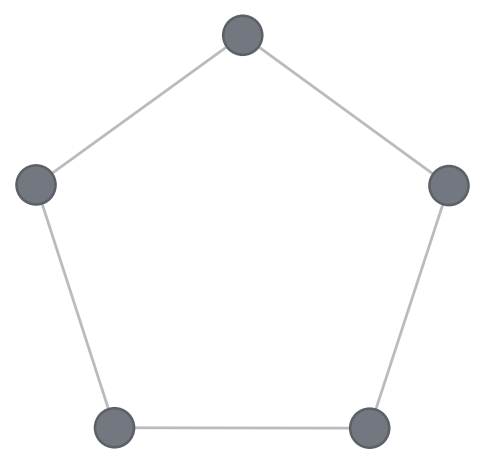

In [163]:
left_defect_op_invariant.draw()

In [164]:
left_defect_op_invariant.contract()

np.float64(0.3081768332726031)

This does not look quite right...

In [165]:
rho_0_l

Tensor(shape=(4, 4), inds=('kl1', 'bl1'), tags=oset([]))

In [166]:
np_rho_0_l = rho_0_l.data

In [170]:
help(left_defect_operator.transpose)

Help on method transpose in module quimb.tensor.tensor_core:

transpose(*output_inds, inplace=False) method of quimb.tensor.tensor_core.Tensor instance
    Transpose this tensor - permuting the order of both the data *and*
    the indices. This operation is mainly for ensuring a certain data
    layout since for most operations the specific order of indices doesn't
    matter.

    Note to compute the tranditional 'transpose' of an operator within a
    contraction for example, you would just use reindexing not this.

    Parameters
    ----------
    output_inds : sequence of str
        The desired output sequence of indices.
    inplace : bool, optional
        Perform the tranposition inplace.

    Returns
    -------
    tt : Tensor
        The transposed tensor.

    See Also
    --------
    transpose_like, reindex



In [173]:
np_left_defect_operator = left_defect_operator.transpose('kl1', 'bl1').data

In [174]:
np.trace(
    np_XX
    @ np_left_defect_operator.conj()
    @ np_XX
    @ np_left_defect_operator
    @ np_rho_0_l
)

np.float64(0.3081768319448079)

Next, more checks. Construct defect operator from entire density matrix.